In [14]:
import gym
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_probability as tfp
import warnings
warnings.filterwarnings('ignore')
import math


Average Reward (Last 100 Episodes): 26.71
Average Reward (Last 100 Episodes): 28.05
Average Reward (Last 100 Episodes): 27.51
Average Reward (Last 100 Episodes): 28.13
Average Reward (Last 100 Episodes): 29.71
Average Reward (Last 100 Episodes): 31.48
Average Reward (Last 100 Episodes): 33.16
Average Reward (Last 100 Episodes): 37.53
Average Reward (Last 100 Episodes): 38.67
Average Reward (Last 100 Episodes): 39.63
Average Reward (Last 100 Episodes): 43.22
Average Reward (Last 100 Episodes): 44.27
Average Reward (Last 100 Episodes): 44.21
Average Reward (Last 100 Episodes): 47.16
Average Reward (Last 100 Episodes): 49.44
Average Reward (Last 100 Episodes): 50.17
Average Reward (Last 100 Episodes): 52.59
Average Reward (Last 100 Episodes): 53.95
Average Reward (Last 100 Episodes): 56.81
Average Reward (Last 100 Episodes): 56.82
Average Reward (Last 100 Episodes): 56.88
Average Reward (Last 100 Episodes): 56.7
Average Reward (Last 100 Episodes): 56.8
Average Reward (Last 100 Episodes): 

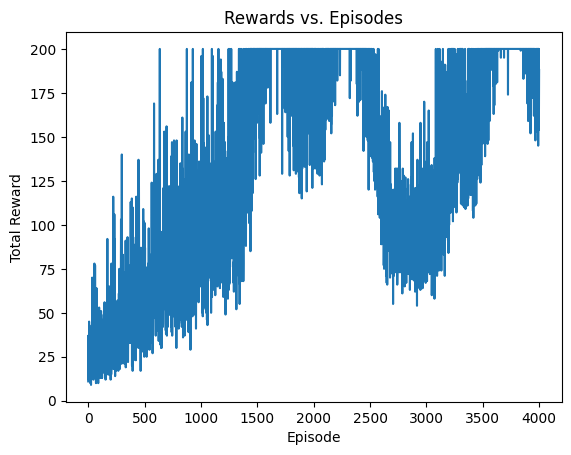

In [16]:
env = gym.make("CartPole-v0")

#  neural network for the policy
model = keras.Sequential([
    keras.layers.Dense(32, activation='linear', input_shape=(4,)),
    keras.layers.Dense(12, activation='relu', input_shape=(32,)),
    keras.layers.Dense(2, activation='softmax')])  # Two actions: left and right])



# optimizer for training
optimizer = keras.optimizers.Adam(learning_rate=0.005)

#  discount factor
gamma = 0.95
#  gradient clipping
max_grad_norm = 1

#num_episodes = 5000

last_100_episodes =[]
episode_rewards = []
for batch in range (0, 200):
    num_episodes = 20
# Training loop
    obs_history_batch = []
    reward_history_batch = []
    action_history_batch = []
    discounted_rewards_batch = []
    loss = 0
    with tf.GradientTape() as tape:
        #tape.watch(model.trainable_variables)
    
        for episode in range(num_episodes):
            obs_history_eps = []
            reward_history_eps = []
            action_history_eps = []
            selected_probs_eps = []


            terminated = False
            truncated = False 

            while (not terminated) and (not truncated):
                # sampling an action from the policy
                #obs_tensor = tf.convert_to_tensor(np.array([obs_history[-1] if obs_history else env.reset()], dtype=np.float32))
                obs_array = np.array(obs_history_eps[-1] if obs_history_eps else env.reset()[0], dtype=np.float32)
                obs_array = obs_array.reshape((1, 4))  # Reshape to 1D array
                obs_tensor =tf.convert_to_tensor(obs_array)



                prob = model(obs_tensor)
                #print("probability", prob)
                dist = tfp.distributions.Categorical(probs=prob, dtype=tf.float32)
                #print("disribution", dist)
                action = dist.sample()
                #print("selected proba", prob[0][int(action)])

                obs, reward, terminated, truncated, info=  env.step(int(action.numpy()[0]))

                obs_history_eps.append(obs)
                reward_history_eps.append(reward)
                action_history_eps.append(action)
                selected_probs_eps.append(prob[0][int(action)])

                obs_history_batch.append(obs)
                reward_history_batch.append(reward)
                action_history_batch.append(action)


            #print(f"CartPole-v0, episode {episode + batch*20}, score {sum(reward_history_eps)}")
            episode_rewards.append(sum(reward_history_eps))

            #  discounted rewards
            discounted_rewards_eps = []
            reward_sum = 0
            for r in reward_history_eps[::-1]:
                reward_sum = r + gamma * reward_sum
                discounted_rewards_eps.insert(0, reward_sum)
            #print(discounted_rewards)

            discounted_rewards_eps = np.array(discounted_rewards_eps)
        #discounted_rewards -= np.mean(discounted_rewards)
        #discounted_rewards /= np.std(discounted_rewards)

        # Compute loss and perform a gradient update

                #loss =0
                #action_prob = model(np.array(obs_history)) #get output of probability actions
                #print(action_prob)
                #action_mask = tf.one_hot(action_history, depth=2) # select probability of the chosen action
                #selected_action_probs = tf.reduce_mean(action_prob * action_mask, axis=1)
                #print(type(selected_action_probs))
                #print(type(discounted_rewards))
            reshaped_discounted_rewards = discounted_rewards_eps.reshape(-1, 1)
            #epsilon = 1e-8
            #log_probs = tf.math.log(selected_action_probs + epsilon)
            #print(log_probs)
            tensor_logprob = tf.math.log(tf.convert_to_tensor(selected_probs_eps, dtype=tf.float32))
            tensor_rewards = tf.convert_to_tensor(reshaped_discounted_rewards, dtype=tf.float32)
            
            loss = loss + tf.reduce_sum (tensor_logprob * tensor_rewards)
            #print(loss)
            #print(loss)
        #print(loss)
        #loss = -loss
        loss = -tf.convert_to_tensor(loss)
    grads = tape.gradient(loss, model.trainable_variables)
    #print("GRADIENT", grads)
#print(grads)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

        if len(episode_rewards) >= 100:
            avg_reward = np.mean(episode_rewards[-100:])
            last_100_episodes.append(avg_reward )
            print(f"Average Reward (Last 100 Episodes): {avg_reward}")

# Plot the rewards

plt.plot(episode_rewards)
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('Rewards vs. Episodes')
plt.show()

'''
fig, ax = plt.subplots()
ax.plot(x1, np.arange(1, len(), label='Plot 1', color='blue')
ax.plot(x2, y2, label='Plot 2', color='red')
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_title('Two Plots in One Graph')
ax.legend()
plt.show()
'''
# Close the environment
env.close()
